In [289]:
import time
import numpy as np
import random as rand
import matplotlib.pyplot as plt

In [290]:
diff_v1 = np.array([4, 0])
diff_v2 = np.array([2, 2])

In [334]:
# L1, L2, and so on
# These operations allow you to determine 
def L(p: int, vector):
    return np.sum(np.abs(vector) ** p, axis=-1) ** (1 / p)

In [292]:
print(f"L1 (v1): {L(1, diff_v1)}")
print(f"L1 (v2): {L(1, diff_v2)}")
print(f"L2 (v1): {L(2, diff_v1)}")
print(f"L2 (v2): {L(2, diff_v2)}")

L1 (v1): 4.0
L1 (v2): 4.0
L2 (v1): 4.0
L2 (v2): 2.8284271247461903


In [293]:
# cosine similarity
# Used to compute the directional similarity of vectors
def cosine_similarity(vector_one, vector_two):
    if (len(vector_one) != len(vector_two)):
        print("Vectors must be same size")
        return 2 # failure

    # store numerator sum, denominator factor one, and denominator factor two
    n = 0
    a = 0
    b = 0
    
    for i in range(len(vector_one)):
        A_i = vector_one[i]
        B_i = vector_two[i]

        # numerator = multiplication of A_i and B_i
        n += A_i * B_i
        # denominator factor one/two is the square of a/b
        a += A_i ** 2
        b += B_i ** 2

    # square root of denominator functions
    a = a ** 0.5
    b = b ** 0.5

    return n / (a * b)

In [294]:
# test cosine similarity
vec_one = [1, 1, 1, 1, 0]
vec_two = [1, 1, 0, 0, 1]

print(cosine_similarity(vec_one, vec_two))

0.5773502691896258


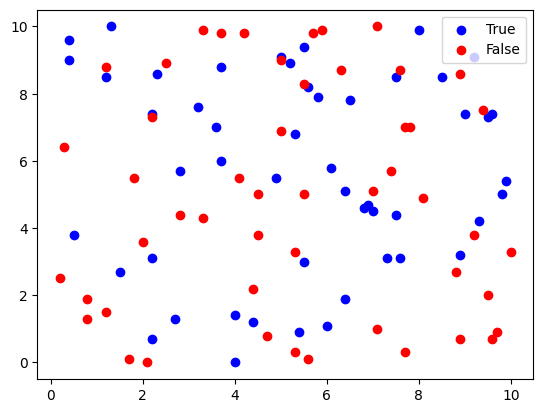

In [354]:
DATA_SIZE = 100
CUT_POINT = int(DATA_SIZE / 2)
# dataset creation
data = []
for i in range(DATA_SIZE):
    data.append([
        round(rand.randint(0, 100) * 0.1, 2), 
        round(rand.randint(0, 100) * 0.1, 2),
        1.0 if i < CUT_POINT else 0.0
    ])

data = np.array(data)

plt.scatter(data[:CUT_POINT, 0], data[:CUT_POINT, 1], color='blue', label="True")
plt.scatter(data[CUT_POINT:, 0], data[CUT_POINT:, 1], color='red', label="False")
plt.legend(loc='upper right')

permutations = np.random.permutation(DATA_SIZE)
dataset = np.array([data[permutations[i]] for i in range(len(permutations))])

In [355]:
# hyper parameters
K = 5
P = 2 # L1 - Manhattan, L2 - Euclidian

In [356]:
point = np.array([7.5, 3.0])

In [357]:
# check if K is too large --> would result in repeats
k = K
if k > CUT_POINT:
    k = CUT_POINT
    print(f"Cropping k to {k}")

tracker = [[0, 10000] for _ in range(k)] # just fill with big numbers

# Non vectorized
for d_point in dataset:
    d_point_x = d_point[0]; d_point_y = d_point[1]; binary=d_point[2]
    diff_vector = point - np.array([d_point_x, d_point_y])
    L_distance = L(p=P, vector=diff_vector)

    for index in range(k):
        if tracker[index][1] > L_distance: 
            tracker[index] = ([binary, L_distance])
            break
tracker = np.array(tracker) 

binary_true = sum(tracker[:, 0])
binary_false = k - binary_true
print(tracker)
print(f"Point is {(binary_true >= binary_false)}: {binary_true} - {binary_false}")
point_binary = (binary_true >= binary_false)

[[1.         0.14142136]
 [1.         1.4       ]
 [1.         1.41421356]
 [1.         2.        ]
 [0.         2.23606798]]
Point is True: 4.0 - 1.0


In [358]:
# vectorized version
coordinates = dataset[:, :2]
labels = dataset[:, 2]

diff_vectors = coordinates - point
distances = L(P, diff_vectors)
nearest_indices = np.argsort(distances)[:k] # arg sort returns indices instead of values in order (smallest -> biggest)

nearest_labels = labels[nearest_indices]
nearest_distances = distances[nearest_indices]
score = nearest_labels.sum()
point_binary = score > (k / 2)
print(f"With score {score} the point given is {point_binary}")

With score 4.0 the point given is True


In [359]:
# super vectorized using linalg.norm
coordinates = dataset[:, :2]
labels = dataset[:, 2]

distances = np.linalg.norm(
    coordinates - point,
    ord=P,
    axis=1
)

nearest_indices = np.argsort(distances)[:k] # arg sort returns indices instead of values in order (smallest -> biggest)

nearest_labels = labels[nearest_indices]
nearest_distances = distances[nearest_indices]
score = nearest_labels.sum()
point_binary = score >= (k / 2)
print(f"With score {score} the point given is {point_binary}")

With score 4.0 the point given is True


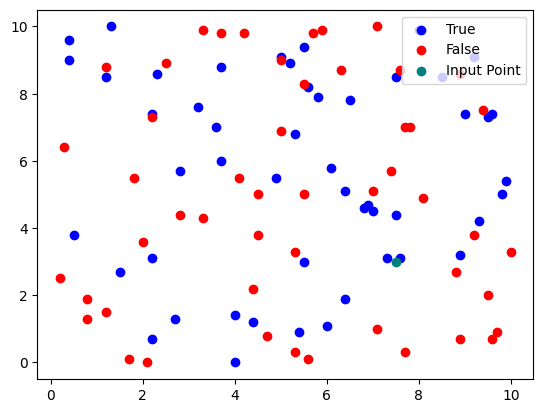

In [360]:
plt.scatter(data[:CUT_POINT, 0], data[:CUT_POINT, 1], color='blue', label="True")
plt.scatter(data[CUT_POINT:, 0], data[CUT_POINT:, 1], color='red', label="False")

# the actual point
plt.scatter(point[0], point[1], color='teal' if point_binary else 'orange', label="Input Point")

plt.legend(loc='upper right')